# Pre-processing
## Lucy Gagnon

In [1]:
#import packages
import numpy as np
import pandas as pd
import glob
import os
import re
import matplotlib.pyplot as plt
import rasterio
from collections import defaultdict
from scipy.spatial import cKDTree

In [6]:
# define functions

# parse date from filename
def parse_date(file):
    # find the 'doyYYYYJJJ...' pattern (e.g. doy2019364000000 -> capture '2019364')
    m = re.search(r'doy(\d{7})', os.path.basename(file))
    if m:
        return m.group(1)
    
#convert key to timestamp
def string_to_timestamp(yyyydoy):
    year = int(yyyydoy[:4])
    doy  = int(yyyydoy[4:7])
    return pd.to_datetime(f"{year}-{doy}", format="%Y-%j")


In [2]:
#load files
files = glob.glob("/shared_space/Galveston_Bay/MODIS_files/*")
#files

In [3]:
#load observed data
file = '/shared_space/Galveston_Bay/All_Observed_Data.csv'
fp = pd.read_csv(file)
#print(fp.head())
lat_obs = fp['lat']
lon_obs = fp['lon']

#print(datetime)
#what are units of DO??
#convert targets to UTC for now
fp['DateTime'] = pd.to_datetime(fp['DateTime'])

# assign LT to ground obs
fp['datetime_local'] = fp['DateTime'].dt.tz_localize('America/Chicago', ambiguous='infer')  # attach tz
# convert ground obs to UTC (easier for merging with ERA, MODIS)
fp['datetime_utc'] = fp['datetime_local'].dt.tz_convert('UTC')
fp['datetime_utc'] = pd.to_datetime(fp['datetime_utc'])
fp['datetime_utc'] = fp['datetime_utc'].dt.tz_localize(None) #remove tz info
y = fp['Value'].values #extract targets
print(fp.head()) #check

             DateTime  Value        lat        lon  \
0 2010-01-04 00:00:00   12.0  29.295779 -94.918220   
1 2010-01-04 00:00:00   10.2  29.503736 -95.098957   
2 2010-01-05 09:02:00    9.7  29.723127 -94.942790   
3 2010-01-05 12:35:00   10.5  29.793630 -95.060914   
4 2010-01-07 00:00:00   10.5  29.591217 -95.042331   

                         source            datetime_local        datetime_utc  
0                   Stream Team 2010-01-04 00:00:00-06:00 2010-01-04 06:00:00  
1                   Stream Team 2010-01-04 00:00:00-06:00 2010-01-04 06:00:00  
2  Regional Monitoring Database 2010-01-05 09:02:00-06:00 2010-01-05 15:02:00  
3  Regional Monitoring Database 2010-01-05 12:35:00-06:00 2010-01-05 18:35:00  
4                   Stream Team 2010-01-07 00:00:00-06:00 2010-01-07 06:00:00  


In [4]:
#load ERA data
import xarray as xr
file = '/shared_space/Galveston_Bay/ERA5/ERA5-2019-2020_v3_rescaled.nc'
ds = xr.open_dataset(file)

#lat_era = ds['lat'].values
#lon_era = ds['lon'].values
#wind_speed = ds['wind_speed'].values
#sst = ds['sst'].values
ds

<xarray.Dataset>
Dimensions:     (latitude: 16, longitude: 21, valid_time: 17544)
Coordinates:
    number      int64 ...
  * valid_time  (valid_time) datetime64[ns] 2019-01-01 ... 2020-12-31T23:00:00
  * latitude    (latitude) float64 28.5 28.6 28.7 28.8 ... 29.7 29.8 29.9 30.0
  * longitude   (longitude) float64 -96.0 -95.9 -95.8 ... -94.2 -94.1 -94.0
Data variables:
    u10         (valid_time, latitude, longitude) float64 ...
    v10         (valid_time, latitude, longitude) float64 ...
    wind_speed  (valid_time, latitude, longitude) float64 ...
    ssr         (valid_time, latitude, longitude) float64 ...
    t2m         (valid_time, latitude, longitude) float64 ...

The ERA5 dataset includes lat, lon, time coordinates for the following variables: u10 and v10, which describe the eastward and northward component of wind, respectively; wind_speed; and sst, which gives sea surface temperature. The coordinates lat, lon are $0.25^o \times 0.25 ^o$ resolution and we have hourly data for 2019-2020. We will ask **Grace** if she already calculates wind_speed from the 10m bands; it seems so. Latitude is decreasing, longitude is increasing (-180,180). The lat, lon are in separate arrays.

In [7]:
#load and group the MODIS red, nir, and qc by date

from collections import defaultdict

# list files
files = glob.glob("/shared_space/Galveston_Bay/MODIS_files/*")
files = sorted(files)

# group files by datetime
groups = defaultdict(list)
for file in files:
    key = parse_date(file)
    #groups[key].append(file)
    if key is None:
        continue      # skip files without a valid date
    groups[key].append(file)
#check
print(len(groups))

365


In [8]:
keys = list(groups.keys())   #extract filenames in groups            
times = np.array([string_to_timestamp(k) for k in keys])
index = pd.DatetimeIndex(times)

## explore MODIS datasets

In [9]:
#load sample MODIS
data_file = '/shared_space/Galveston_Bay/MODIS_files/MYD09GQ.061_sur_refl_b01_1_doy2019364000000_aid0001.tif'

In [10]:
import rasterio
# Open the TIFF file in read mode ('r')
with rasterio.open(data_file, 'r') as dataset:
    # You can now access various properties of the dataset
    print(f"Driver: {dataset.driver}")
    print(f"CRS: {dataset.crs}")
    print(f"Bounds: {dataset.bounds}")
    print(f"Width: {dataset.width}")
    print(f"Height: {dataset.height}")
    print(f"Number of bands: {dataset.count}")
    print(f"Band 1 data type: {dataset.dtypes[0]}")

    # To read the entire image (or a specific band) as a NumPy array:
    # For a single-band image:
    band1_data = dataset.read(1) 
    print(f"Shape of band 1 data: {band1_data.shape}")

    # For a multi-band image, you can read all bands at once or individual bands
    # all_bands_data = dataset.read() # Reads all bands into a 3D NumPy array
    # band2_data = dataset.read(2) # Reads the second band


Driver: GTiff
CRS: EPSG:4326
Bounds: BoundingBox(left=-96.00208332473296, bottom=28.49999999744682, right=-93.99999999157899, top=30.00208333064559)
Width: 961
Height: 721
Number of bands: 1
Band 1 data type: int16
Shape of band 1 data: (721, 961)


/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:27: RuntimeWarning: invalid value encountered in true_divide


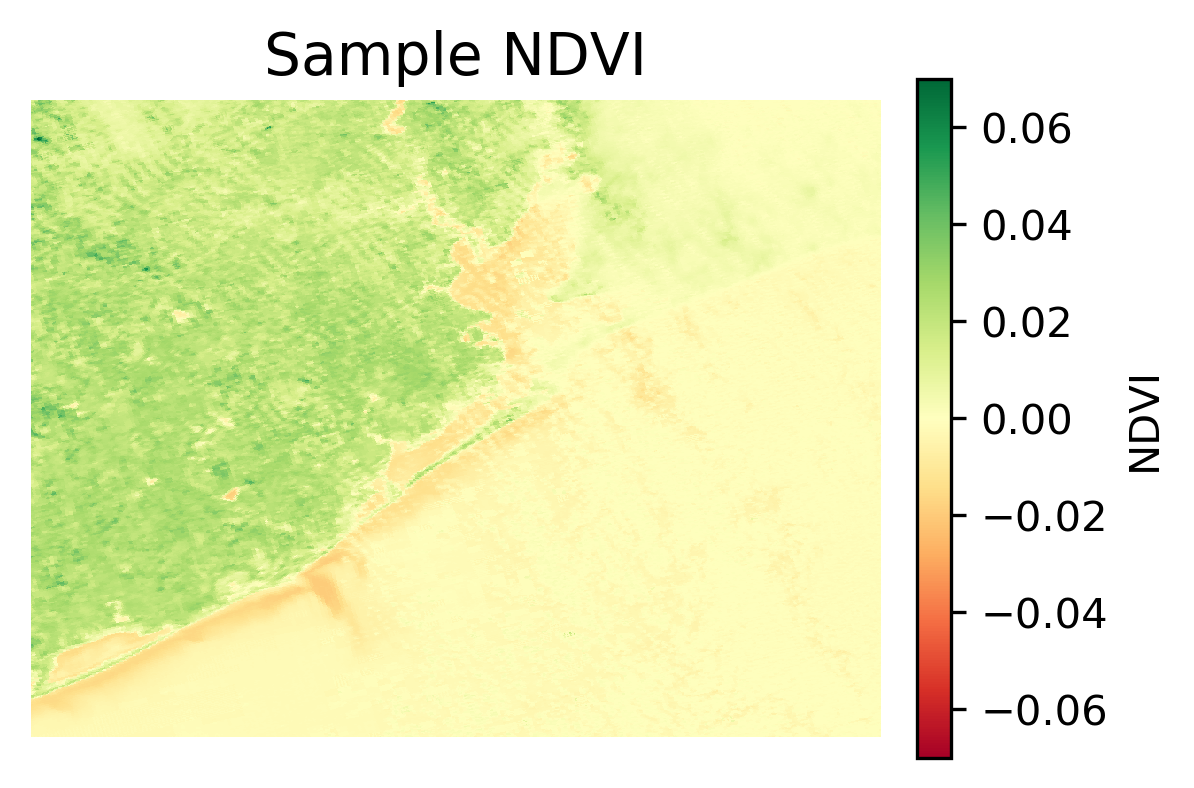

In [11]:
#red band path
#red_path = '/shared_space/Galveston_Bay/MODIS_files/MYD09GQ.061_sur_refl_b01_1_doy2019364000000_aid0001.tif'
red_path = '/shared_space/Galveston_Bay/MODIS_files/MYD09GQ.061_sur_refl_b01_1_doy2019019000000_aid0001.tif'
 
#nir path
#nir_path = '/shared_space/Galveston_Bay/MODIS_files/MYD09GQ.061_sur_refl_b02_1_doy2019364000000_aid0001.tif'
nir_path = '/shared_space/Galveston_Bay/MODIS_files/MYD09GQ.061_sur_refl_b02_1_doy2019019000000_aid0001.tif'
 
#normalize RGB values to 0-1 using min-max normalization
def normalize(array):
    array_min, array_max = array.min(), array.max() #find min and max of array
    return (array - array_min) / (array_max - array_min) #min-max norm calc
# read arrays
with rasterio.open(red_path) as red_src, rasterio.open(nir_path) as nir_src:
    red = red_src.read(1).astype(float) #convert to floats
    nir = nir_src.read(1).astype(float)
    
    width = red_src.width
    height = red_src.height
    transform = red_src.transform  # Affine transformation matrix

# normalize to 0–1
red_norm = normalize(red)
nir_norm = normalize(nir)

# compute NDVI
ndvi = (nir_norm - red_norm) / (nir_norm + red_norm)
import matplotlib.pyplot as plt
%matplotlib inline

# plot NDVI
plt.figure(figsize=(4,3), dpi = 300)
ndvi_plot = plt.imshow(ndvi, cmap='RdYlGn', vmin = -0.07, vmax = 0.07) #ndvi varies btw -1 and 1
#customize colorbar
plt.colorbar(ndvi_plot, fraction=0.046, pad=0.04, label="NDVI")
#plot properties
plt.title("Sample NDVI", fontsize =14)
plt.axis("off")
plt.show()

In [12]:
import numpy as np
cols, rows = np.meshgrid(np.arange(width), np.arange(height))


In [13]:
xs, ys = rasterio.transform.xy(transform, rows, cols)
lons = np.array(xs)
lats = np.array(ys)


In [14]:
# Example: Get latitude and longitude for a specific pixel (e.g., top-left)
top_left_lon = lons[0, 0]
top_left_lat = lats[0, 0]

print(f"Top-left longitude: {top_left_lon}")
print(f"Top-left latitude: {top_left_lat}")


Top-left longitude: -96.00104165806638
Top-left latitude: 30.001041663979017


In [15]:

date_string = parse_date(red_path)
print(date_string)

2019019


In [16]:
import pandas as pd
date = string_to_timestamp(date_string)
print(date)

2019-01-19 00:00:00


In [17]:
from datetime import datetime

target_timestamp = date

closest_timestamp = min(fp['datetime_utc'], key=lambda ts: abs(target_timestamp - ts))
print(closest_timestamp)


2019-01-15 19:09:00


In [18]:
ys = np.array(ys)
xs = np.array(xs)

In [19]:
import numpy as np

# Example meshgrid (replace with your actual lat/lon arrays)
#lat_grid = np.linspace(30, 40, 100)
#lon_grid = np.linspace(-100, -90, 100)
#lon_mesh, lat_mesh = np.meshgrid(lon_grid, lat_grid)

# Target point
target_lat = 29
target_lon = -95.2

# Calculate squared differences (simpler than Haversine for nearest on grid)
lat_diff_sq = (ys - target_lat)**2
lon_diff_sq = (xs - target_lon)**2

# Sum of squared differences for "distance" on the grid
# (This assumes a roughly square grid cell, or you can use Haversine for accuracy)
distance_sq = lat_diff_sq + lon_diff_sq

# Find the index of the minimum distance
min_idx = np.unravel_index(np.argmin(distance_sq), distance_sq.shape)

# Get the nearest grid point coordinates
nearest_lat = ys[min_idx]
nearest_lon = xs[min_idx]

print(f"Nearest grid point: Lat={nearest_lat}, Lon={nearest_lon}")


Nearest grid point: Lat=29.0010416640686, Lon=-95.20104165813805


In [20]:
print(red_norm)

[[0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.75143065 0.75143065 ... 0.94191551 0.94191551 0.95226823]
 [0.         0.75143065 0.75756945 ... 0.93895016 0.93895016 0.93895016]
 ...
 [0.         0.74726875 0.74726875 ... 0.92261471 0.92261471 0.92261471]
 [0.         0.75192488 0.74698262 ... 0.8962647  0.8962647  0.8962647 ]
 [0.         0.75192488 0.74698262 ... 0.91280824 0.8962647  0.8962647 ]]


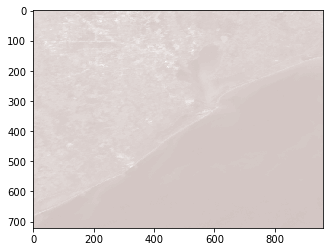

In [21]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.imshow(band1_data, cmap = 'terrain')


### match MODIS and targets

In [22]:


# configurations
SCALE = 0.0001                # MODIS SUR_REFL scale factor
TIME_TOL = pd.Timedelta("96h")# max allowed difference between obs and MODIS scene
USE_FALLBACK = True          # set True to enable KDTree fallback (more expensive)
FALLBACK_MAX_KM = 100.0        # max distance to accept fallback pixel

# extract YYYYDDD from filename
def extract_year_doy(s):
    if s is None:
        return None
    s = str(s)
    m = re.search(r'doy(\d{7})', s, flags=re.IGNORECASE)
    if m:
        return m.group(1)
    m2 = re.search(r'(\d{4})(\d{3})', s)
    if m2:
        return m2.group(1) + m2.group(2)
    return None
#convert string to timestamp
def year_doy_to_ts(yyyydoy):
    year = int(yyyydoy[:4]); doy = int(yyyydoy[4:7])
    return pd.to_datetime(f"{year}-{doy}", format="%Y-%j")

# build valid scene keys and index
raw_keys = list(groups.keys())
scene_keys = []
bad_keys = []
for k in raw_keys:
    ek = extract_year_doy(k)
    if ek is not None:
        scene_keys.append(ek)
    else:
        bad_keys.append(k)
if len(scene_keys) == 0:
    raise RuntimeError("No valid scene keys parsed from groups.")
scene_times = [year_doy_to_ts(k) for k in scene_keys]
scene_index = pd.DatetimeIndex(scene_times)

# match nearest datetime
# ensure fp['datetime_utc'] is datetime64 (naive UTC)
#fp['datetime_utc'] = pd.to_datetime(fp['datetime_utc'])
# convert tz-aware to UTC naive if needed
#if getattr(fp['datetime_utc'].dt, 'tz', None) is not None:
#    fp['datetime_utc'] = fp['datetime_utc'].dt.tz_convert('UTC').dt.tz_localize(None)
#extract index
idx_for_obs = scene_index.get_indexer(fp['datetime_utc'], method='nearest', tolerance=TIME_TOL)
fp['modis_scene_idx'] = idx_for_obs 
# store time diff in minutes
matched_times = pd.Series([scene_index[i] if i >= 0 else pd.NaT for i in idx_for_obs], index=fp.index)
fp['modis_time_diff_min'] = (fp['datetime_utc'] - matched_times).abs().dt.total_seconds() / 60.0

# init output cols
fp['modis_red'] = np.nan
fp['modis_nir'] = np.nan
fp['modis_ratio'] = np.nan
fp['modis_ndvi'] = np.nan
fp['modis_pixel_dist_km'] = np.nan   # filled only by fallback if used

# -------- Optional helper: great-circle distance from chord --------
def great_circle_km_from_chord(chord):
    R = 6371.0
    central = 2 * np.arcsin(np.clip(chord / 2.0, 0, 1.0))
    return R * central

# match by lat lon
for scene_idx, scene_key in enumerate(scene_keys):
    # find obs indices assigned to this scene
    obs_idx = np.where(fp['modis_scene_idx'].values == scene_idx)[0]
    if obs_idx.size == 0:
        continue

    # find files for this group (allow fallback: try searching flist for a matching key)
    flist = groups.get(scene_key, None)
    if flist is None:
        # fallback: try to find a group whose filename contains scene_key
        candidates = [g for g in groups.values() if any(scene_key in os.path.basename(p) for p in g)]
        flist = candidates[0] if candidates else None
    if not flist:
        # nothing to process for this scene
        continue

    red_fp = next((f for f in flist if '_sur_refl_b01' in os.path.basename(f).lower()), None)
    nir_fp = next((f for f in flist if '_sur_refl_b02' in os.path.basename(f).lower()), None)
    qc_fp  = next((f for f in flist if '_qc' in os.path.basename(f).lower()), None)
    if not (red_fp and nir_fp and qc_fp):
        # skip incomplete scenes
        continue

    # build coords in obs order
    coords = [(fp.loc[i,'lon'], fp.loc[i,'lat']) for i in obs_idx]

    # open rasters and batch-sample at coords
    with rasterio.open(red_fp) as rsrc, rasterio.open(nir_fp) as nsrc, rasterio.open(qc_fp) as qsrc:
        raw_red = np.array([v[0] for v in rsrc.sample(coords)], dtype=np.float32)
        raw_nir = np.array([v[0] for v in nsrc.sample(coords)], dtype=np.float32)
        raw_qc  = np.array([v[0] for v in qsrc.sample(coords)], dtype=np.uint16)

        # decode QC on sampled QC values (vectorized)
        modland_qa = raw_qc & 0b11
        produced   = (raw_qc & (1 << 2)) == 0
        aerosol_ok = (raw_qc & 0b11110000) == 0
        good_sample = np.isin(modland_qa, [0,1]) & produced & aerosol_ok
        #good_sample = np.isin(modland_qa, [0,1])

        # mask sampled values and scale
        red_sample = raw_red.astype(np.float32)
        nir_sample = raw_nir.astype(np.float32)
        red_sample[~good_sample] = np.nan
        nir_sample[~good_sample] = np.nan
        red_sample *= SCALE
        nir_sample *= SCALE

        # compute derived indices vectorized (safe against div/0)
        with np.errstate(invalid='ignore', divide='ignore'):
            ratio_sample = red_sample / nir_sample
            nd_sample = (red_sample - nir_sample) / (red_sample + nir_sample)

        # optionally fallback to nearest valid ocean pixel (heavy: build KDTree once)
        pixel_dist_km = np.full(red_sample.shape, np.nan, dtype=float)
        if USE_FALLBACK and np.any(np.isnan(red_sample)):
            # read full arrays once to build KDTree of valid pixels
            full_red = rsrc.read(1).astype(np.float32)
            full_qc  = qsrc.read(1).astype(np.uint16)
            # reconstruct good-mask on full grid (same bit logic)
            modland_full = full_qc & 0b11
            produced_full = (full_qc & (1<<2)) == 0
            aerosol_full = (full_qc & 0b11110000) == 0
            good_full = np.isin(modland_full, [0,1]) & produced_full & aerosol_full
            good_rows, good_cols = np.where(good_full)
            if good_rows.size > 0:
                # coords of valid pixels
                lons, lats = rasterio.transform.xy(rsrc.transform, good_rows, good_cols, offset='center')
                lons = np.array(lons); lats = np.array(lats)
                lat_r = np.deg2rad(lats); lon_r = np.deg2rad(lons)
                x = np.cos(lat_r) * np.cos(lon_r)
                y = np.cos(lat_r) * np.sin(lon_r)
                z = np.sin(lat_r)
                pts = np.column_stack((x,y,z))
                tree = cKDTree(pts)

                # query for needed obs (unit-sphere coords)
                need_idx = np.where(np.isnan(red_sample))[0]
                if need_idx.size > 0:
                    obs_lats = np.deg2rad(fp.loc[obs_idx,'lat'].values[need_idx])
                    obs_lons = np.deg2rad(fp.loc[obs_idx,'lon'].values[need_idx])
                    qx = np.cos(obs_lats) * np.cos(obs_lons)
                    qy = np.cos(obs_lats) * np.sin(obs_lons)
                    qz = np.sin(obs_lats)
                    qpts = np.column_stack((qx,qy,qz))
                    chords, idxs = tree.query(qpts, k=1)
                    dists = great_circle_km_from_chord(chords)
                    accept = dists <= FALLBACK_MAX_KM
                    # assign fallback values where accepted
                    for ii, accept_flag in enumerate(accept):
                        if not accept_flag:
                            continue
                        tgt_idx = need_idx[ii]
                        matched = idxs[ii]
                        # matched maps to good_rows[matched], good_cols[matched]
                        r = good_rows[matched]; c = good_cols[matched]
                        rv = full_red[r, c] * SCALE
                        nv = np.nan  # optionally read full_nir if needed for nv; here we set nv=nan if not read
                        # safer: read full_nir once as well (similar to full_red) to compute nv
                        # for brevity, assume full_nir read earlier if you want full fallback
                        red_sample[tgt_idx] = rv
                        pixel_dist_km[tgt_idx] = dists[ii]

        # assign sampled results back to fp (vectorized)
        out_vals = np.column_stack((red_sample, nir_sample, ratio_sample, nd_sample, pixel_dist_km))
        cols = ['modis_red','modis_nir','modis_ratio','modis_ndvi','modis_pixel_dist_km']
        fp.loc[fp.index[obs_idx], cols] = out_vals



In [23]:
print(fp.head())

             DateTime  Value        lat        lon  \
0 2010-01-04 00:00:00   12.0  29.295779 -94.918220   
1 2010-01-04 00:00:00   10.2  29.503736 -95.098957   
2 2010-01-05 09:02:00    9.7  29.723127 -94.942790   
3 2010-01-05 12:35:00   10.5  29.793630 -95.060914   
4 2010-01-07 00:00:00   10.5  29.591217 -95.042331   

                         source            datetime_local        datetime_utc  \
0                   Stream Team 2010-01-04 00:00:00-06:00 2010-01-04 06:00:00   
1                   Stream Team 2010-01-04 00:00:00-06:00 2010-01-04 06:00:00   
2  Regional Monitoring Database 2010-01-05 09:02:00-06:00 2010-01-05 15:02:00   
3  Regional Monitoring Database 2010-01-05 12:35:00-06:00 2010-01-05 18:35:00   
4                   Stream Team 2010-01-07 00:00:00-06:00 2010-01-07 06:00:00   

   modis_scene_idx  modis_time_diff_min  modis_red  modis_nir  modis_ratio  \
0               -1                  NaN        NaN        NaN          NaN   
1               -1              

In [24]:
print("obs min/max:", fp['datetime_utc'].min(), fp['datetime_utc'].max())
print("sample obs (2019-2020):")
print(fp[(fp['datetime_utc'] >= '2019-01-01') & (fp['datetime_utc'] < '2021-01-01')].head(15))
print(len(fp[(fp['datetime_utc'] >= '2019-01-01') & (fp['datetime_utc'] < '2021-01-01')]))


obs min/max: 2010-01-04 06:00:00 2025-08-17 13:53:00
sample obs (2019-2020):
                DateTime  Value        lat        lon  \
1925 2019-01-04 11:04:00    9.1  29.770000 -94.916100   
1926 2019-01-07 09:55:00    8.4  29.408054 -94.951599   
1927 2019-01-07 09:55:00    8.3  29.408054 -94.951599   
1928 2019-01-07 11:25:00    7.7  29.533890 -95.034805   
1929 2019-01-07 11:25:00    7.4  29.533890 -95.034805   
1930 2019-01-07 11:25:00    7.9  29.533890 -95.034805   
1931 2019-01-08 10:30:00   10.2  29.793630 -95.060914   
1932 2019-01-08 11:37:00   10.2  29.793630 -95.060914   
1933 2019-01-09 12:08:00    0.9  29.353390 -95.030380   
1934 2019-01-15 11:13:00   10.6  29.584800 -95.045890   
1935 2019-01-15 11:24:00   10.0  29.601503 -95.043712   
1936 2019-01-15 11:36:00   10.5  29.606810 -95.045675   
1937 2019-01-15 11:43:00    7.6  29.351390 -95.015114   
1938 2019-01-15 11:43:00    7.7  29.351390 -95.015114   
1939 2019-01-15 11:43:00    4.6  29.351390 -95.015114   

          

In [25]:
print(lat_obs)

0       29.295779
1       29.503736
2       29.723127
3       29.793630
4       29.591217
5       29.723127
6       29.675556
7       29.675556
8       29.675556
9       29.683161
10      29.584167
11      29.584167
12      29.563698
13      29.456134
14      29.683161
15      29.565576
16      29.607305
17      29.584536
18      29.295779
19      29.793630
20      29.563698
21      29.683161
22      29.456134
23      29.793630
24      29.793630
25      29.793630
26      29.793630
27      29.607305
28      29.584536
29      29.565576
          ...    
3106    29.506500
3107    29.569982
3108    29.529115
3109    29.304190
3110    29.387030
3111    29.453800
3112    29.652910
3113    29.619129
3114    29.551040
3115    29.547250
3116    29.506500
3117    29.534689
3118    29.534440
3119    29.569982
3120    29.529115
3121    29.453800
3122    29.595497
3123    29.453800
3124    29.453830
3125    29.534440
3126    29.595497
3127    29.595497
3128    29.534440
3129    29.453800
3130    29

In [26]:
print(len(y))

651624


In [27]:
y = fp['Value'].values

In [28]:
print(fp.columns)

Index(['DateTime', 'Value', 'lat', 'lon', 'source', 'datetime_local',
       'datetime_utc', 'modis_scene_idx', 'modis_time_diff_min', 'modis_red',
       'modis_nir', 'modis_ratio', 'modis_ndvi', 'modis_pixel_dist_km'],
      dtype='object')


In [29]:
print(fp)

                DateTime  Value        lat        lon  \
0    2010-01-04 00:00:00  12.00  29.295779 -94.918220   
1    2010-01-04 00:00:00  10.20  29.503736 -95.098957   
2    2010-01-05 09:02:00   9.70  29.723127 -94.942790   
3    2010-01-05 12:35:00  10.50  29.793630 -95.060914   
4    2010-01-07 00:00:00  10.50  29.591217 -95.042331   
5    2010-01-13 09:50:00  11.10  29.723127 -94.942790   
6    2010-01-19 12:20:00   8.00  29.675556 -94.666110   
7    2010-01-19 12:20:00   7.70  29.675556 -94.666110   
8    2010-01-19 12:20:00   7.80  29.675556 -94.666110   
9    2010-01-19 12:37:00   8.70  29.683161 -94.622400   
10   2010-01-19 13:10:00   8.50  29.584167 -94.494450   
11   2010-01-19 13:10:00   8.60  29.584167 -94.494450   
12   2010-01-22 00:00:00  11.70  29.563698 -95.066042   
13   2010-01-26 00:00:00   8.00  29.456134 -95.053732   
14   2010-01-26 17:10:00   7.80  29.683161 -94.622400   
15   2010-01-29 00:00:00   8.50  29.565576 -95.054155   
16   2010-01-29 00:00:00   7.20

In [30]:
import numpy as np

# 1) era vars and observation-level vars
era_vars = list(ds.data_vars)   # e.g. ['u10', 'v10', 'sst', ...]
obs_vars = ['modis_time_diff_min', 'modis_red', 'modis_nir', 'modis_ratio', 'modis_nd']

n_obs = len(fp)                # must align with y, lat_obs, lon_obs
n_pred = len(era_vars) + len(obs_vars)

# helper extractor (unchanged)
def extract_at_site_and_time(da, sitetime, site_lat, site_lon):
    # ensure sitetime is a numpy/pandas Timestamp that matches ds time coord dtype
    sel = da.sel({'latitude': site_lat, 'longitude': site_lon, 'valid_time': sitetime},
                 method='nearest')
    val = np.asarray(sel.values).squeeze()
    # if val is a masked or nan-friendly dtype, convert to float and handle
    return float(val) if np.isfinite(val) else np.nan

# 2) Pre-allocate X
X = np.full((n_obs, n_pred), np.nan, dtype=float)

# 3) Loop over observations (use iloc for positional indexing)
for i in range(n_obs):
    s_lat = lat_obs.iloc[i] if hasattr(lat_obs, 'iloc') else lat_obs[i]
    s_lon = lon_obs.iloc[i] if hasattr(lon_obs, 'iloc') else lon_obs[i]
    s_time = pd.to_datetime(fp['datetime_utc'].iloc[i])   # ensure Timestamp

    # ERA5 variables first
    for j, varname in enumerate(era_vars):
        try:
            X[i, j] = extract_at_site_and_time(ds[varname], s_time, s_lat, s_lon)
        except Exception:
            # graceful fallback if variable missing or selection fails
            X[i, j] = np.nan

    # observation-level variables appended after era_vars
    base = len(era_vars)
    for k, col in enumerate(obs_vars):
        # Use .iloc to get scalar; if missing in fp, produce NaN
        try:
            val = fp[col].iloc[i]
            # if it's a pandas Timestamp, convert to float or leave NaN depending on usage
            X[i, base + k] = float(val) if np.isfinite(val) else np.nan
        except Exception:
            X[i, base + k] = np.nan

# final checks
print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (3136, 10)
y shape: (3136,)


In [31]:
print(X)

[[0.07944824 0.26134094 0.27315035 ...        nan        nan        nan]
 [0.02546387 1.10571594 1.10600911 ...        nan        nan        nan]
 [0.01366699 1.20852844 1.20860572 ...        nan        nan        nan]
 ...
 [6.42218933 4.01543579 7.57418249 ...        nan        nan        nan]
 [6.42218933 4.01543579 7.57418249 ...        nan        nan        nan]
 [6.42218933 4.01543579 7.57418249 ...        nan        nan        nan]]


In [32]:
header_line  = [era_vars+obs_vars]
print(header_line)
header_line = 'u10, v10, wind_speed, ssr, t2m, modis_time_diff_min, red, nir, red_over_nir, ndvi'

[['u10', 'v10', 'wind_speed', 'ssr', 't2m', 'modis_time_diff_min', 'modis_red', 'modis_nir', 'modis_ratio', 'modis_nd']]


In [33]:
import numpy as np

np.savetxt('samples.csv', X, delimiter=',', fmt='%.2f', header=header_line, comments='')
np.savetxt('targets.csv', y, delimiter=',', fmt='%.2f', header='ground_obs', comments='')

In [ ]:
#KEEP only wind_speed and sst ( has lots of NaNs so be careful)
#X = np.delete(X, [0, 1], axis=1)
print(X)

In [ ]:
## step 4: outlier detection
import matplotlib.pyplot as plt
%matplotlib inline
plt.hist(X[:,0], bins=30, edgecolor='black')  # 'bins' controls the number of bars, 'edgecolor' adds borders

# Add labels and title for clarity
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Wind Speed Data")

# Display the plot
plt.show()


plt.hist(X[:,1], bins=30, edgecolor='black')  # 'bins' controls the number of bars, 'edgecolor' adds borders

# Add labels and title for clarity
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Sea Surface Temperature Data")

# Display the plot
plt.show()

In [ ]:
## step 5: feature selection

In [ ]:
feature_names = ['windspeed', 'ssr', 't2m', ]